# Laboratorio 4, Parte 2: clasificación geoespacial de cianobacteria

**CC3084 – Data Science**  
**Integrantes:** Iris Ayala, Anggie Quezada y Jonathan Diaz

Esta entrega parcial reproduce, sin red ni credenciales, los ejercicios 1–7 y la validación temporal a partir de los 22 GeoTIFF locales de Sentinel-2.

> **Alcance científico.** La respuesta representa una categoría construida a partir de un **proxy satelital** de clorofila-a y la detección espectral FAI; no es una medición sanitaria, una identificación taxonómica de cianobacterias ni una medición de toxinas. Los resultados sirven para priorizar observación y muestreo de campo, no para emitir alertas de salud pública.

## Método reproducible y controles contra fuga

- Se leen únicamente `data/raw/<lago>/*.tif` y su producto alineado en `data/processed`; no se realiza adquisición.
- La población elegible exige agua, máscara válida, `dataMask=1`, exclusión SCL de NoData/defectos/sombra/nube/cirrus/nieve y valores espectrales finitos.
- La respuesta es estrictamente `0/1`: `1` si el proxy es ≥20 o el detector FAI marca floración superficial; `0` en caso contrario. El umbral de 20 µg/L-equivalente es un corte operacional coherente con el análisis de Parte 1 y con un estado eutrófico aproximado en la escala trófica de Carlson. **No se interpreta como límite sanitario.**
- La transformación NDCI–clorofila sigue el modelo del script CyanoLakes descrito por Kravitz y Matthews (2020). La incertidumbre de transferencia óptica y la falta de validación in situ obligan a hablar de proxy.
- Se excluyen de los predictores el target, proxy, NDCI, FAI/floración, B04, B05, B07 y B8A. También se excluye NDVI porque usa B04. NDVI y NDWI se conservan en el dataset por la rúbrica, pero no entrenan los modelos. Coordenadas, fecha y lago se conservan para validación y trazabilidad, pero tampoco se usan como predictores para impedir memorización espacial/temporal o de identidad del lago.
- Predictores defendibles: B02, B03, B08, B11 y B12. No forman NDCI ni FAI. Aunque algunas participan en la máscara de agua, no construyen directamente la respuesta.
- Para limitar costo, se toma una muestra determinista (`seed=42`) de hasta 500 observaciones por lago–fecha–clase. Antes del muestreo se guardan conteos completos de población. Así nunca se materializan los 16.5 millones de píxeles, inválidos en su mayoría.

**Referencias.** Carlson, R. E. (1977), *A trophic state index for lakes*, Limnology and Oceanography 22(2), 361–369, https://doi.org/10.4319/lo.1977.22.2.0361. Kravitz, J. y Matthews, M. (2020), *Chlorophyll-a for cyanobacteria blooms from Sentinel-2*, Remote Sensing of Environment 247, 111906, https://doi.org/10.1016/j.rse.2020.111906. WHO (2021), *Guidelines on recreational water quality, Volume 1*; la evaluación sanitaria requiere evidencia adicional, no solo color oceánico.

In [1]:
from io import BytesIO
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, display

from lab4_ds.ml import (
    PREDICTORS,
    TARGET_THRESHOLD,
    add_spatial_blocks,
    build_ml_dataset,
    chronological_split_indices,
    evaluate_cross_lake,
    evaluate_models,
    evaluate_spatial_cv,
    evaluate_temporal_holdout,
    random_split_indices,
    tune_models,
)

RANDOM_STATE = 42
EVIDENCE_DIR = Path("outputs/tables")
EVIDENCE_DIR.mkdir(parents=True, exist_ok=True)
pd.set_option("display.max_columns", 30)
pd.set_option("display.precision", 4)
sns.set_theme(style="whitegrid", context="notebook")


def display_figure(figure):
    # Render explicitly because the execution environment uses the non-interactive Agg backend.
    buffer = BytesIO()
    figure.savefig(buffer, format="png", dpi=120, bbox_inches="tight")
    display(Image(data=buffer.getvalue()))
    plt.close(figure)

## Ejercicio 1 — Preparación, limpieza y EDA

La función reutilizable recorre cada escena una sola vez, calcula estadísticas sobre todos los píxeles y materializa únicamente la muestra estratificada válida. Las coordenadas corresponden al centro de cada píxel según el `Affine` del GeoTIFF.

In [2]:
bundle = build_ml_dataset(maximum_per_scene_class=500, random_state=RANDOM_STATE)
data = bundle.sample
population = bundle.population

population.to_csv(EVIDENCE_DIR / "ml_population_by_scene.csv", index=False)

global_population = population[["raster_pixels", "valid_water_pixels", "eligible_pixels", "class_0", "class_1", "sampled_pixels"]].sum().to_frame("count")
by_lake = population.groupby("lake")[["raster_pixels", "valid_water_pixels", "eligible_pixels", "class_0", "class_1", "sampled_pixels"]].sum()

print(f"Observaciones elegibles en la población: {population['eligible_pixels'].sum():,}")
print(f"Observaciones en la muestra reproducible: {len(data):,}")
print(f"Escenas locales: {len(population)}")
display(global_population)
display(by_lake)
display(population)

Observaciones elegibles en la población: 2,055,768
Observaciones en la muestra reproducible: 18,568
Escenas locales: 22


,count
raster_pixels,16513585
valid_water_pixels,2629943
eligible_pixels,2055768
class_0,1952211
class_1,103557
sampled_pixels,18568


,raster_pixels,valid_water_pixels,eligible_pixels,class_0,class_1,sampled_pixels
lake,,,,,,
amatitlan,3375460,258091,258052,172558,85494,10128
atitlan,13138125,2371852,1797716,1779653,18063,8440


,lake,date,raster_pixels,valid_water_pixels,eligible_pixels,class_0,class_1,sampled_pixels
0,amatitlan,2025-01-28,306860,27830,27823,22364,5459,1000
1,amatitlan,2025-04-15,306860,11760,11759,10315,1444,1000
2,amatitlan,2025-04-28,306860,23244,23232,17782,5450,1000
3,amatitlan,2025-11-24,306860,30045,30038,25516,4522,1000
4,amatitlan,2026-01-08,306860,31327,31319,18723,12596,1000
5,amatitlan,2026-02-02,306860,2578,2577,2577,0,500
6,amatitlan,2026-02-07,306860,9076,9075,8947,128,628
7,amatitlan,2026-03-29,306860,22581,22581,17444,5137,1000
8,amatitlan,2026-04-13,306860,34704,34702,27472,7230,1000
9,amatitlan,2026-04-28,306860,33462,33462,19302,14160,1000


In [3]:
schema = pd.DataFrame({
    "variable": data.columns,
    "dtype": data.dtypes.astype(str).values,
    "missing_n": data.isna().sum().values,
    "missing_percent": (data.isna().mean().mul(100)).values,
})
display(schema)
display(data.describe(include="all").T)

,variable,dtype,missing_n,missing_percent
0,longitude,float64,0,0.0
1,latitude,float64,0,0.0
2,date,datetime64[s],0,0.0
3,lake,object,0,0.0
4,B02,float32,0,0.0
5,B03,float32,0,0.0
6,B04,float32,0,0.0
7,B05,float32,0,0.0
8,B07,float32,0,0.0
9,B08,float32,0,0.0


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
longitude,18568.0,NaN,NaN,NaN,-90.8513,-91.2862,-91.1832,-90.6021,-90.5638,-90.5291,0.3142
latitude,18568.0,NaN,NaN,NaN,14.5636,14.4124,14.4515,14.4822,14.6932,14.7477,0.1196
date,18568,NaN,NaN,NaN,2025-11-19 10:35:55,2025-01-18 00:00:00,2025-05-13 00:00:00,2026-01-08 00:00:00,2026-04-13 00:00:00,2026-07-22 00:00:00,NaN
lake,18568,2,amatitlan,10128,NaN,NaN,NaN,NaN,NaN,NaN,NaN
B02,18568.0,NaN,NaN,NaN,0.0268,0.0027,0.0142,0.0233,0.034,0.8065,0.0191
B03,18568.0,NaN,NaN,NaN,0.0351,0.0058,0.0145,0.0228,0.0571,0.763,0.0285
B04,18568.0,NaN,NaN,NaN,0.0184,0.0001,0.0062,0.0123,0.0299,0.7322,0.0192
B05,18568.0,NaN,NaN,NaN,0.0335,0.0001,0.007,0.0183,0.0581,0.7486,0.0345
B07,18568.0,NaN,NaN,NaN,0.0235,0.0,0.0051,0.0104,0.0361,0.6747,0.0303
B08,18568.0,NaN,NaN,NaN,0.0203,0.0,0.0041,0.0092,0.0311,0.6548,0.0276


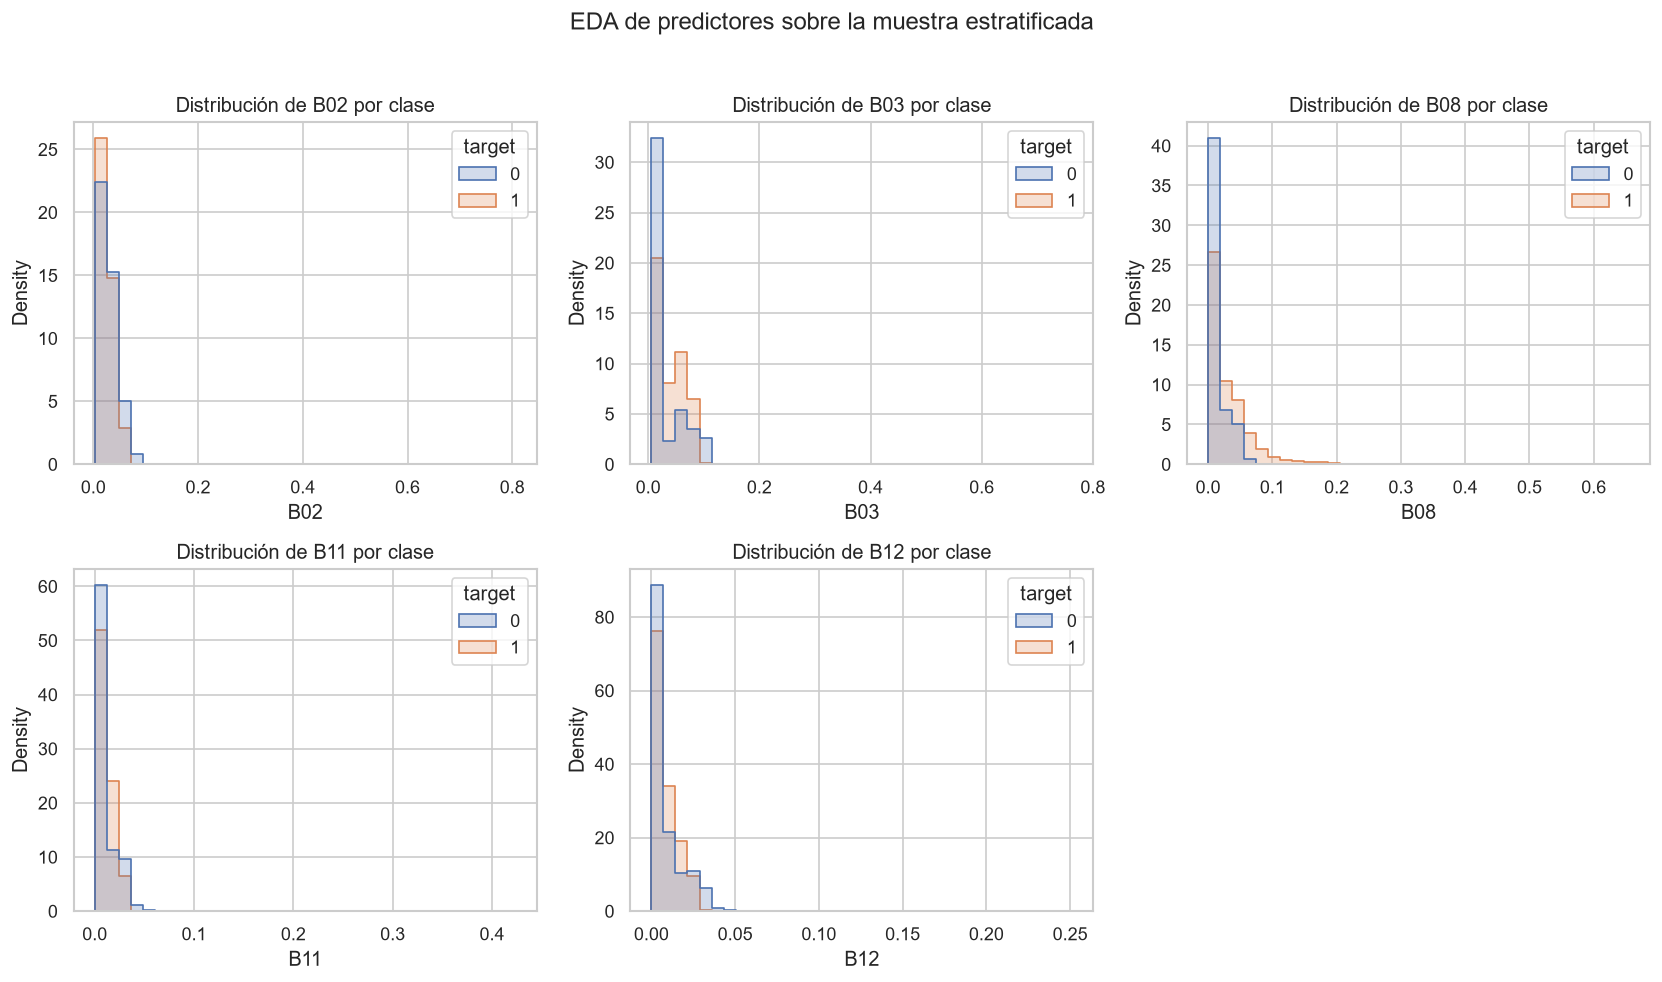

B02             B03             B08             B11  \
                    mean     std    mean     std    mean     std    mean   
lake      target                                                           
amatitlan 0       0.0331  0.0292  0.0495  0.0356  0.0222  0.0235  0.0162   
          1       0.0304  0.0149  0.0519  0.0224  0.0362  0.0313  0.0133   
atitlan   0       0.0228  0.0071  0.0168  0.0059  0.0062  0.0037  0.0045   
          1       0.0166  0.0064  0.0164  0.0106  0.0183  0.0380  0.0047   

                             B12          
                     std    mean     std  
lake      target                          
amatitlan 0       0.0157  0.0141  0.0122  
          1       0.0085  0.0109  0.0074  
atitlan   0       0.0031  0.0039  0.0026  
          1       0.0047  0.0041  0.0037

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for variable, axis in zip(PREDICTORS, axes.flat, strict=False):
    sns.histplot(data=data, x=variable, hue="target", bins=35, stat="density", common_norm=False, element="step", ax=axis)
    axis.set_title(f"Distribución de {variable} por clase")
axes.flat[-1].axis("off")
fig.suptitle("EDA de predictores sobre la muestra estratificada", y=1.02)
plt.tight_layout()
display_figure(fig)

display(data.groupby(["lake", "target"])[list(PREDICTORS)].agg(["mean", "std"]).round(4))

**Interpretación del ejercicio 1.** Los conteos de población, y no la muestra balanceada por estratos, son la referencia para describir cobertura y prevalencia. La muestra solo reduce el costo de entrenamiento. No hay imputación: una observación con predictor no finito queda excluida. La unidad observacional sigue siendo el píxel-fecha; por ello existe dependencia entre píxeles vecinos y entre observaciones repetidas de una zona, problema que se trata explícitamente en las validaciones espacial y temporal.

## Ejercicio 2 — Respuesta binaria, distribución y desbalance

La clase positiva combina dos ramas del algoritmo de origen: proxy NDCI ≥20 y FAI de floración superficial. Este diseño evita convertir la ausencia de una estimación de clorofila en un negativo cuando FAI detecta una capa superficial. El corte es útil como regla de análisis ambiental, pero **no demuestra presencia de una especie, toxicidad ni riesgo sanitario**.

Prevalencia positiva real: 5.04%
Razón mayoría/minoría: 18.85:1


,count
class_0,1952211
class_1,103557


,class_0,class_1,positive_percent
lake,,,
amatitlan,172558,85494,33.1305
atitlan,1779653,18063,1.0048


,lake,date,class_0,class_1,positive_percent
0,amatitlan,2025-01-28,22364,5459,19.6205
1,amatitlan,2025-04-15,10315,1444,12.2800
2,amatitlan,2025-04-28,17782,5450,23.4590
3,amatitlan,2025-11-24,25516,4522,15.0543
4,amatitlan,2026-01-08,18723,12596,40.2184
5,amatitlan,2026-02-02,2577,0,0.0000
6,amatitlan,2026-02-07,8947,128,1.4105
7,amatitlan,2026-03-29,17444,5137,22.7492
8,amatitlan,2026-04-13,27472,7230,20.8345
9,amatitlan,2026-04-28,19302,14160,42.3167


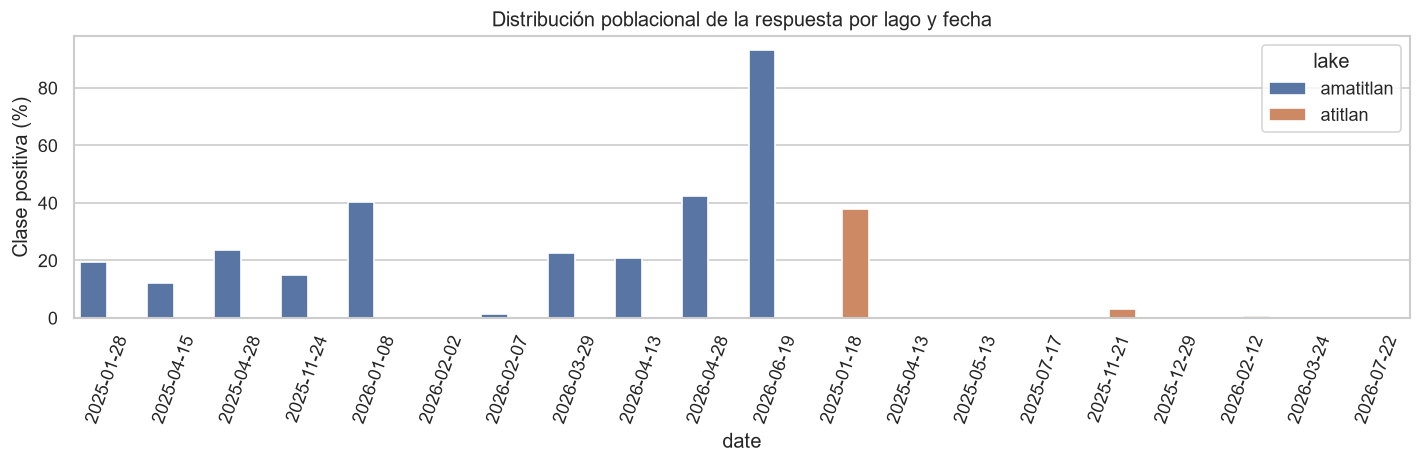

In [5]:
population_distribution = population[["class_0", "class_1"]].sum()
population_prevalence = population_distribution["class_1"] / population_distribution.sum()
distribution_by_lake = population.groupby("lake")[["class_0", "class_1"]].sum()
distribution_by_lake["positive_percent"] = 100 * distribution_by_lake["class_1"] / distribution_by_lake[["class_0", "class_1"]].sum(axis=1)
distribution_by_date = population[["lake", "date", "class_0", "class_1"]].copy()
distribution_by_date["positive_percent"] = 100 * distribution_by_date["class_1"] / distribution_by_date[["class_0", "class_1"]].sum(axis=1)

print(f"Prevalencia positiva real: {population_prevalence:.2%}")
print(f"Razón mayoría/minoría: {population_distribution.max() / population_distribution.min():.2f}:1")
display(population_distribution.to_frame("count"))
display(distribution_by_lake)
display(distribution_by_date)

fig, ax = plt.subplots(figsize=(12, 4))
sns.barplot(data=distribution_by_date, x="date", y="positive_percent", hue="lake", ax=ax)
ax.tick_params(axis="x", rotation=70)
ax.set_ylabel("Clase positiva (%)")
ax.set_title("Distribución poblacional de la respuesta por lago y fecha")
plt.tight_layout()
display_figure(fig)

**Consecuencia del desbalance.** Accuracy puede parecer alta si un modelo favorece la clase mayoritaria. Por eso se reportan precision, recall, F1 y ROC-AUC, se usan pesos balanceados y se ajustan hiperparámetros con F2, que pondera recall más que precision. Ambientalmente, un falso negativo puede omitir una zona que merece inspección; un falso positivo consume recursos de verificación. Se prioriza reducir falsos negativos sin afirmar que toda señal positiva sea una floración tóxica.

Como el test proviene de la muestra estratificada, precision, accuracy y matrices describen ese diseño de evaluación y no una prevalencia operativa de campo. Para estimar valores predictivos en despliegue sería necesario validar sobre una muestra representativa o recalibrar con la prevalencia poblacional.

**Fuga identificada.** `target`, `cyanobacteria_proxy`, `ndci`, `surface_bloom`, B04/B05 (NDCI), B04/B07/B8A (FAI) y cualquier clase derivada están prohibidos. NDVI también queda fuera porque usa B04. NDWI se conserva, pero se excluye del modelo para mantener un conjunto espectral simple y evitar incorporar un índice ya empleado en la selección de agua.

## Ejercicio 3 — Selección y justificación de variables

In [6]:
variable_catalog = pd.DataFrame([
    ("B02", "Azul", "Banda espectral", "Sí", "Respuesta óptica independiente de NDCI/FAI; puede capturar dispersión y turbidez."),
    ("B03", "Verde", "Banda espectral", "Sí", "Aporta contraste del agua y material suspendido sin formar el target."),
    ("B04", "Rojo", "Banda espectral", "No", "Fuga: participa en NDCI y FAI."),
    ("B05", "Borde rojo 1", "Banda espectral", "No", "Fuga: participa directamente en NDCI."),
    ("B07", "Borde rojo 3", "Banda espectral", "No", "Fuga: participa directamente en FAI."),
    ("B08", "Infrarrojo cercano", "Banda espectral", "Sí", "Describe respuesta del agua/partículas y no forma NDCI ni FAI."),
    ("B8A", "NIR estrecho", "Banda espectral", "No", "Fuga: participa directamente en FAI."),
    ("B11", "SWIR 1", "Banda espectral", "Sí", "Puede capturar humedad y contraste agua-tierra; independiente del target."),
    ("B12", "SWIR 2", "Banda espectral", "Sí", "Complementa discriminación espectral del agua sin formar el target."),
    ("NDVI", "Vegetación", "Índice", "No", "Se conserva por rúbrica, pero usa B04, banda del target."),
    ("NDWI", "Agua", "Índice", "No", "Se conserva para EDA; ya interviene conceptualmente en selección de agua."),
    ("NDCI/proxy/FAI", "Señal objetivo", "Índice/derivada", "No", "Construyen directa o indirectamente la respuesta."),
    ("Longitud/latitud", "Posición", "Espacial", "No", "Se usan para bloques; entrenar con ellas memorizaría zonas."),
    ("Fecha", "Adquisición", "Temporal", "No", "Se usa para corte cronológico; no se codifica para evitar memorizar campañas."),
    ("Lago", "Identidad", "Categórica", "No", "Se conserva para estratos y reporte; podría inflar generalización interna."),
], columns=["variable", "meaning", "class", "used_as_predictor", "justification"])
display(variable_catalog)
print("Predictores finales:", ", ".join(PREDICTORS))

,variable,meaning,class,used_as_predictor,justification
0,B02,Azul,Banda espectral,Sí,Respuesta óptica independiente de NDCI/FAI; pu...
1,B03,Verde,Banda espectral,Sí,Aporta contraste del agua y material suspendid...
2,B04,Rojo,Banda espectral,No,Fuga: participa en NDCI y FAI.
3,B05,Borde rojo 1,Banda espectral,No,Fuga: participa directamente en NDCI.
4,B07,Borde rojo 3,Banda espectral,No,Fuga: participa directamente en FAI.
5,B08,Infrarrojo cercano,Banda espectral,Sí,Describe respuesta del agua/partículas y no fo...
6,B8A,NIR estrecho,Banda espectral,No,Fuga: participa directamente en FAI.
7,B11,SWIR 1,Banda espectral,Sí,Puede capturar humedad y contraste agua-tierra...
8,B12,SWIR 2,Banda espectral,Sí,Complementa discriminación espectral del agua ...
9,NDVI,Vegetación,Índice,No,"Se conserva por rúbrica, pero usa B04, banda d..."


Predictores finales: B02, B03, B08, B11, B12


No se agrega ingeniería de características: cocientes o índices nuevos podrían reconstruir parcialmente la señal objetivo, y con solo 22 fechas aumentarían complejidad sin evidencia independiente. Esta decisión favorece auditabilidad sobre una mejora aparente.

## Ejercicios 4 y 5 — Modelos, ajuste y evaluación aleatoria común

In [7]:
random_train, random_test = random_split_indices(data, random_state=RANDOM_STATE)
models, tuning = tune_models(data, random_train, random_state=RANDOM_STATE)
random_metrics = evaluate_models(models, data, random_test, strategy="random_70_30")

tuning.to_csv(EVIDENCE_DIR / "ml_tuning.csv", index=False)
random_metrics.to_csv(EVIDENCE_DIR / "ml_random_metrics.csv", index=False)

print(f"Train: {len(random_train):,} ({len(random_train)/len(data):.1%}); test común: {len(random_test):,} ({len(random_test)/len(data):.1%})")
display(tuning)
display(random_metrics)

Train: 12,997 (70.0%); test común: 5,571 (30.0%)


,model,best_cv_f2,best_params
0,Logistic regression,0.7143,{'classifier__C': 3.0}
1,Random forest,0.8619,"{'classifier__max_depth': None, 'classifier__m..."
2,Gradient boosting,0.8325,{'classifier__learning_rate': 0.1}


,strategy,model,n_test,accuracy,precision,recall,f1,roc_auc,tn,fp,fn,tp
0,random_70_30,Logistic regression,5571,0.7421,0.6757,0.7063,0.6906,0.8610,2530,770,667,1604
1,random_70_30,Random forest,5571,0.8718,0.8251,0.8701,0.8470,0.9501,2881,419,295,1976
2,random_70_30,Gradient boosting,5571,0.8397,0.7805,0.8441,0.8111,0.9201,2761,539,354,1917


Los tres modelos usan exactamente el mismo test estratificado 30 %. El ajuste ocurre solo dentro del 70 % de training mediante validación estratificada de tres folds. Se exploran rejillas pequeñas para controlar costo: `C` en logística; profundidad y mínimo por hoja en Random Forest; tasa de aprendizaje en Gradient Boosting. El criterio F2 prioriza sensibilidad sin ignorar precision. Los pesos de clase se calculan únicamente sobre cada training.

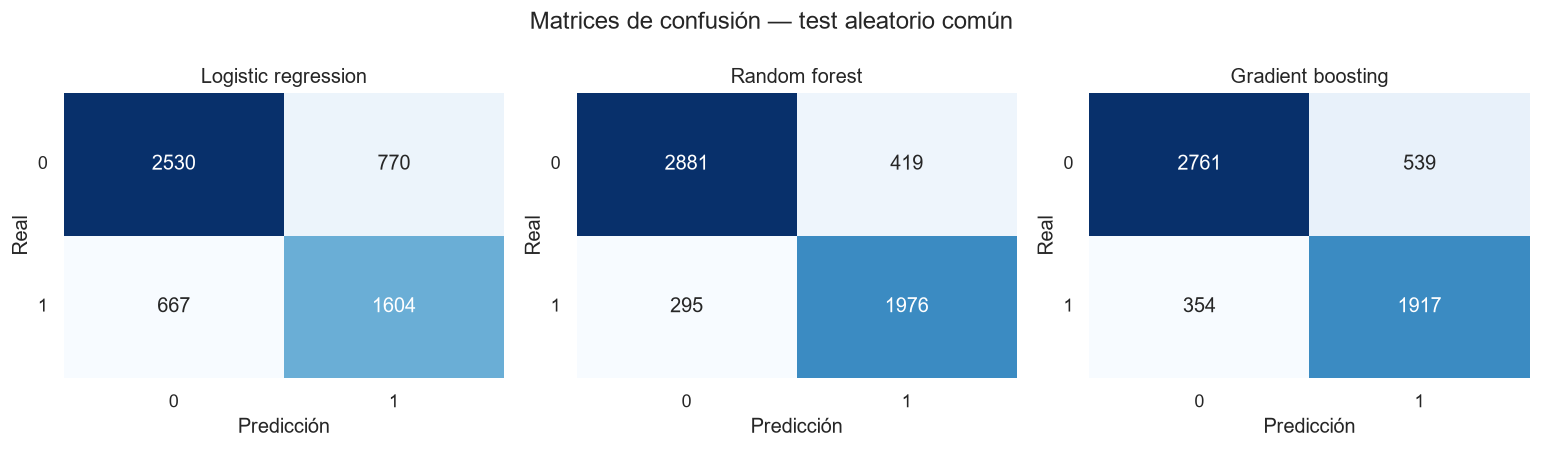

Mayor recall aleatorio: Random forest (0.870); falsos negativos: 295.
La selección ambiental se apoya primero en recall y después en F1; ROC-AUC describe ordenamiento, no el costo operativo del umbral 0.5.


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for axis, row in zip(axes, random_metrics.itertuples(), strict=True):
    matrix = np.array([[row.tn, row.fp], [row.fn, row.tp]])
    sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axis)
    axis.set_title(row.model)
    axis.set_xlabel("Predicción")
    axis.set_ylabel("Real")
    axis.set_xticklabels([0, 1])
    axis.set_yticklabels([0, 1], rotation=0)
plt.suptitle("Matrices de confusión — test aleatorio común")
plt.tight_layout()
display_figure(fig)

best_random = random_metrics.sort_values(["recall", "f1"], ascending=False).iloc[0]
print(f"Mayor recall aleatorio: {best_random['model']} ({best_random['recall']:.3f}); falsos negativos: {best_random['fn']}.")
print("La selección ambiental se apoya primero en recall y después en F1; ROC-AUC describe ordenamiento, no el costo operativo del umbral 0.5.")

## Ejercicio 6 — Validación espacial con bloques de 1 km

In [9]:
spatial_data = add_spatial_blocks(data, block_size_m=1_000)
block_counts = spatial_data.groupby(["lake", "spatial_block"], as_index=False).agg(observations=("target", "size"), positives=("target", "sum"), dates=("date", "nunique"))
block_summary = block_counts.groupby("lake").agg(blocks=("spatial_block", "nunique"), min_observations=("observations", "min"), median_observations=("observations", "median"), max_observations=("observations", "max"), total_observations=("observations", "sum"))

block_counts.to_csv(EVIDENCE_DIR / "ml_spatial_block_counts.csv", index=False)
display(block_summary)
display(block_counts)

,blocks,min_observations,median_observations,max_observations,total_observations
lake,,,,,
amatitlan,40,1,192.5,888,10128
atitlan,163,1,53.0,221,8440


,lake,spatial_block,observations,positives,dates
0,amatitlan,amatitlan_757_1601,1,1,1
1,amatitlan,amatitlan_757_1602,95,70,8
2,amatitlan,amatitlan_757_1603,63,55,6
3,amatitlan,amatitlan_758_1601,366,186,9
4,amatitlan,amatitlan_758_1602,601,388,10
...,...,...,...,...,...
198,atitlan,atitlan_702_1621,1,0,1
199,atitlan,atitlan_702_1622,17,4,8
200,atitlan,atitlan_702_1623,19,5,8
201,atitlan,atitlan_702_1624,12,2,7


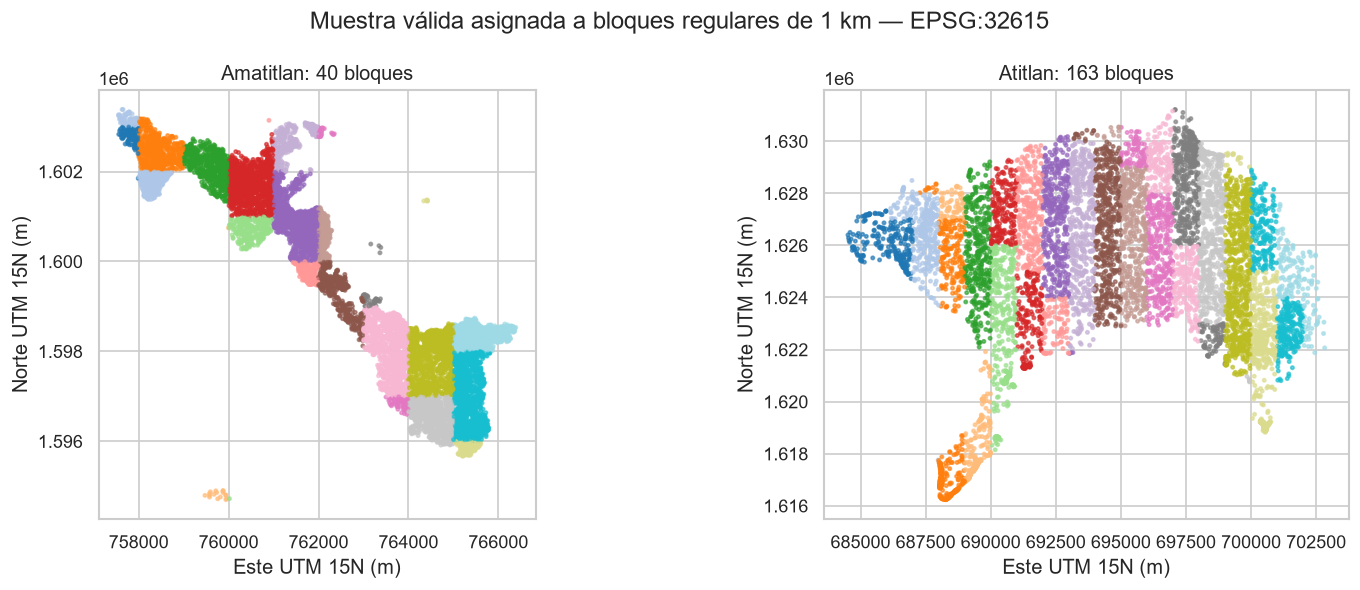

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for axis, (lake, lake_data) in zip(axes, spatial_data.groupby("lake"), strict=True):
    block_codes = pd.Categorical(lake_data["spatial_block"]).codes
    scatter = axis.scatter(lake_data["x_utm"], lake_data["y_utm"], c=block_codes, s=4, cmap="tab20", alpha=0.65)
    axis.set_title(f"{lake.title()}: {lake_data['spatial_block'].nunique()} bloques")
    axis.set_xlabel("Este UTM 15N (m)")
    axis.set_ylabel("Norte UTM 15N (m)")
    axis.set_aspect("equal")
plt.suptitle("Muestra válida asignada a bloques regulares de 1 km — EPSG:32615")
plt.tight_layout()
display_figure(fig)

El tamaño solicitado produce varios grupos con observaciones en ambos lagos y permite cinco folds externos. El identificador incluye lago y celda, por lo que una celda nunca se comparte entre training y validación. La evaluación es **anidada**: para cada test espacial externo se realiza un tuning nuevo dentro del training externo mediante GroupKFold interno de tres folds. Tanto los folds externos como los internos mantienen bloques íntegros; ninguna etiqueta del test externo participa en la selección de hiperparámetros. Si un test fold contiene una sola clase, ROC-AUC se deja como `NaN`; no se inventa un valor.

In [11]:
spatial_folds, spatial_tuning = evaluate_spatial_cv(
    spatial_data, n_splits=5, inner_splits=3, random_state=RANDOM_STATE
)
spatial_folds.to_csv(EVIDENCE_DIR / "ml_spatial_fold_metrics.csv", index=False)
spatial_tuning.to_csv(EVIDENCE_DIR / "ml_spatial_tuning.csv", index=False)
spatial_summary = spatial_folds[spatial_folds["status"] == "ok"].groupby("model", as_index=False)[["accuracy", "precision", "recall", "f1", "roc_auc"]].mean()
display(spatial_folds)
display(spatial_tuning)
display(spatial_summary)
assert spatial_tuning["outer_test_tuning_overlap"].eq(0).all()
assert spatial_tuning["maximum_inner_group_overlap"].eq(0).all()

,strategy,fold,model,n_test,test_classes,status,accuracy,precision,recall,f1,roc_auc,tn,fp,fn,tp
0,spatial,1,Logistic regression,3714,2,ok,0.7577,0.7614,0.7354,0.7482,0.8745,1477,419,481,1337
1,spatial,1,Random forest,3714,2,ok,0.8487,0.8348,0.8614,0.8479,0.9364,1586,310,252,1566
2,spatial,1,Gradient boosting,3714,2,ok,0.8158,0.7987,0.8339,0.8159,0.8999,1514,382,302,1516
3,spatial,2,Logistic regression,3714,2,ok,0.6793,0.5581,0.6902,0.6172,0.8266,1563,760,431,960
4,spatial,2,Random forest,3714,2,ok,0.8656,0.7710,0.9123,0.8357,0.9539,1946,377,122,1269
5,spatial,2,Gradient boosting,3714,2,ok,0.8363,0.7436,0.8591,0.7972,0.9256,1911,412,196,1195
6,spatial,3,Logistic regression,3714,2,ok,0.7582,0.7226,0.6717,0.6962,0.8618,1787,395,503,1029
7,spatial,3,Random forest,3714,2,ok,0.8549,0.8343,0.8087,0.8213,0.9370,1936,246,293,1239
8,spatial,3,Gradient boosting,3714,2,ok,0.8374,0.8061,0.7977,0.8018,0.9182,1888,294,310,1222
9,spatial,4,Logistic regression,3713,2,ok,0.7681,0.6585,0.7181,0.6870,0.8806,1907,490,371,945


,model,best_inner_f2,best_params,outer_fold,outer_train_n,outer_test_n,outer_test_tuning_overlap,maximum_inner_group_overlap
0,Logistic regression,0.6938,{'classifier__C': 3.0},1,14854,3714,0,0
1,Random forest,0.8292,"{'classifier__max_depth': None, 'classifier__m...",1,14854,3714,0,0
2,Gradient boosting,0.7926,{'classifier__learning_rate': 0.1},1,14854,3714,0,0
3,Logistic regression,0.7294,{'classifier__C': 3.0},2,14854,3714,0,0
4,Random forest,0.8313,"{'classifier__max_depth': None, 'classifier__m...",2,14854,3714,0,0
5,Gradient boosting,0.7946,{'classifier__learning_rate': 0.1},2,14854,3714,0,0
6,Logistic regression,0.7105,{'classifier__C': 3.0},3,14854,3714,0,0
7,Random forest,0.8426,"{'classifier__max_depth': None, 'classifier__m...",3,14854,3714,0,0
8,Gradient boosting,0.8061,{'classifier__learning_rate': 0.1},3,14854,3714,0,0
9,Logistic regression,0.7082,{'classifier__C': 3.0},4,14855,3713,0,0


,model,accuracy,precision,recall,f1,roc_auc
0,Gradient boosting,0.8282,0.7664,0.8329,0.7969,0.9143
1,Logistic regression,0.7440,0.6751,0.7182,0.6941,0.8636
2,Random forest,0.8549,0.7965,0.8664,0.8282,0.9412


## Validación temporal — entrenamiento en pasado, evaluación en futuro

In [12]:
temporal_train, temporal_test, temporal_cutoff = chronological_split_indices(data, train_fraction=0.70)
temporal_metrics, temporal_tuning = evaluate_temporal_holdout(
    data,
    temporal_train,
    temporal_test,
    inner_splits=3,
    random_state=RANDOM_STATE,
)
temporal_metrics.to_csv(EVIDENCE_DIR / "ml_temporal_metrics.csv", index=False)
temporal_tuning.to_csv(EVIDENCE_DIR / "ml_temporal_tuning.csv", index=False)

print(f"Última fecha de training: {pd.Timestamp(data.iloc[temporal_train]['date'].max()).date()}")
print(f"Primera fecha de test: {pd.Timestamp(data.iloc[temporal_test]['date'].min()).date()}")
print(f"Training temporal: {len(temporal_train):,}; test futuro: {len(temporal_test):,}")
print("Fechas de test:", ", ".join(str(pd.Timestamp(value).date()) for value in sorted(data.iloc[temporal_test]['date'].unique())))
display(temporal_metrics)
display(temporal_tuning)
assert temporal_tuning["future_test_tuning_overlap"].eq(0).all()
assert (temporal_tuning["latest_tuning_date"] < temporal_tuning["earliest_future_test_date"]).all()

Última fecha de training: 2026-02-12
Primera fecha de test: 2026-03-24
Training temporal: 12,115; test futuro: 6,453
Fechas de test: 2026-03-24, 2026-03-29, 2026-04-13, 2026-04-28, 2026-06-19, 2026-07-22


,strategy,model,n_test,accuracy,precision,recall,f1,roc_auc,tn,fp,fn,tp
0,temporal,Logistic regression,6453,0.8872,0.9430,0.7485,0.8345,0.9503,3889,111,617,1836
1,temporal,Random forest,6453,0.8298,0.7627,0.8019,0.7818,0.9231,3388,612,486,1967
2,temporal,Gradient boosting,6453,0.7753,0.6587,0.8488,0.7417,0.8664,2921,1079,371,2082


,model,best_inner_f2,best_params,past_train_n,future_test_n,future_test_tuning_overlap,latest_tuning_date,earliest_future_test_date
0,Logistic regression,0.5740,{'classifier__C': 3.0},12115,6453,0,2026-02-12,2026-03-24
1,Random forest,0.7167,"{'classifier__max_depth': 8, 'classifier__min_...",12115,6453,0,2026-02-12,2026-03-24
2,Gradient boosting,0.7208,{'classifier__learning_rate': 0.05},12115,6453,0,2026-02-12,2026-03-24


El corte se calcula sobre fechas globalmente ordenadas: 70 % de fechas tempranas para training y 30 % posteriores para test. Por construcción, `max(train_date) < min(test_date)`. El tuning temporal también es independiente: usa tres divisiones internas de ventana expansiva dentro del período pasado, y en cada una las fechas de entrenamiento preceden estrictamente a las fechas de validación. Luego se reajusta la mejor configuración sobre todo el pasado y se evalúa una sola vez sobre el futuro. Ni etiquetas ni filas futuras intervienen en la selección.

,model,accuracy,precision,recall,f1,roc_auc,strategy
2,Gradient boosting,0.8397,0.7805,0.8441,0.8111,0.9201,random_70_30
3,Gradient boosting,0.8282,0.7664,0.8329,0.7969,0.9143,spatial_groupkfold
8,Gradient boosting,0.7753,0.6587,0.8488,0.7417,0.8664,temporal_future
0,Logistic regression,0.7421,0.6757,0.7063,0.6906,0.8610,random_70_30
4,Logistic regression,0.7440,0.6751,0.7182,0.6941,0.8636,spatial_groupkfold
6,Logistic regression,0.8872,0.9430,0.7485,0.8345,0.9503,temporal_future
1,Random forest,0.8718,0.8251,0.8701,0.8470,0.9501,random_70_30
5,Random forest,0.8549,0.7965,0.8664,0.8282,0.9412,spatial_groupkfold
7,Random forest,0.8298,0.7627,0.8019,0.7818,0.9231,temporal_future


strategy,random_70_30,spatial_groupkfold,temporal_future,spatial_minus_random,temporal_minus_random
model,,,,,
Gradient boosting,0.8441,0.8329,0.8488,-0.0113,0.0046
Logistic regression,0.7063,0.7182,0.7485,0.0119,0.0422
Random forest,0.8701,0.8664,0.8019,-0.0037,-0.0682


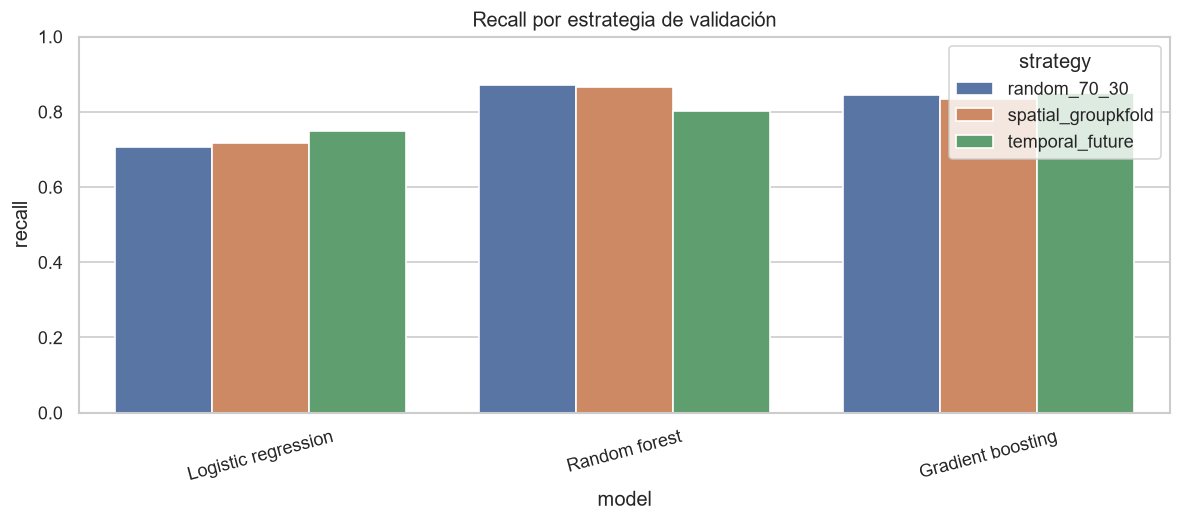

In [13]:
random_comparison = random_metrics[["model", "accuracy", "precision", "recall", "f1", "roc_auc"]].assign(strategy="random_70_30")
spatial_comparison = spatial_summary.assign(strategy="spatial_groupkfold")
temporal_comparison = temporal_metrics[["model", "accuracy", "precision", "recall", "f1", "roc_auc"]].assign(strategy="temporal_future")
comparison = pd.concat([random_comparison, spatial_comparison, temporal_comparison], ignore_index=True)
comparison.to_csv(EVIDENCE_DIR / "ml_validation_comparison.csv", index=False)
display(comparison.sort_values(["model", "strategy"]))

recall_pivot = comparison.pivot(index="model", columns="strategy", values="recall")
recall_pivot["spatial_minus_random"] = recall_pivot["spatial_groupkfold"] - recall_pivot["random_70_30"]
recall_pivot["temporal_minus_random"] = recall_pivot["temporal_future"] - recall_pivot["random_70_30"]
display(recall_pivot)

fig, ax = plt.subplots(figsize=(10, 4.5))
sns.barplot(data=comparison, x="model", y="recall", hue="strategy", ax=ax)
ax.set_ylim(0, 1)
ax.set_title("Recall por estrategia de validación")
plt.xticks(rotation=15)
plt.tight_layout()
display_figure(fig)

### Interpretación conjunta

La división aleatoria mezcla píxeles vecinos y fechas de una misma escena entre train y test, de modo que puede beneficiarse de autocorrelación y producir una estimación optimista. GroupKFold pregunta si el modelo se desplaza a bloques no vistos, mientras que el corte temporal pregunta si se mantiene en adquisiciones futuras. Las diferencias de recall mostradas arriba cuantifican esa pérdida o ganancia para cada modelo. Con solo 22 escenas, estas métricas tienen incertidumbre y no sustituyen una campaña externa.

El resultado más realista depende del uso: para visitar una nueva zona del mismo sistema, validación espacial; para pronosticar una campaña posterior, validación temporal. La transferencia entre lagos se evalúa separadamente a continuación.

## Ejercicio 7 — Generalización entre lagos

Se ejecutan los dos sentidos exigidos con los tres modelos. En cada experimento, el lago externo queda completamente aislado: preprocesamiento, pesos, selección F2 e hiperparámetros se ajustan únicamente con el lago de entrenamiento. El CV interno usa tres folds `GroupKFold` sobre bloques de 1 km del lago de entrenamiento; luego el modelo seleccionado se reajusta con todo ese lago y se evalúa una sola vez sobre el otro.

In [14]:
cross_lake_metrics, cross_lake_tuning = evaluate_cross_lake(
    spatial_data,
    inner_splits=3,
    random_state=RANDOM_STATE,
)
cross_lake_metrics.to_csv(EVIDENCE_DIR / "ml_cross_lake_metrics.csv", index=False)
cross_lake_tuning.to_csv(EVIDENCE_DIR / "ml_cross_lake_tuning.csv", index=False)

assert cross_lake_tuning["evaluation_tuning_overlap"].eq(0).all()
assert cross_lake_tuning["maximum_inner_group_overlap"].eq(0).all()
display(cross_lake_metrics)
display(cross_lake_tuning)

baseline = random_metrics[["model", "accuracy", "precision", "recall", "f1", "roc_auc"]].rename(
    columns={metric: f"mixed_random_{metric}" for metric in ["accuracy", "precision", "recall", "f1", "roc_auc"]}
)
cross_lake_comparison = cross_lake_metrics.merge(baseline, on="model", how="left")
for metric in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
    cross_lake_comparison[f"delta_{metric}"] = cross_lake_comparison[metric] - cross_lake_comparison[f"mixed_random_{metric}"]
cross_lake_comparison.to_csv(EVIDENCE_DIR / "ml_cross_lake_comparison.csv", index=False)
display(cross_lake_comparison)

,strategy,experiment,train_lake,evaluation_lake,model,n_train,n_test,test_classes,accuracy,precision,recall,f1,roc_auc,tn,fp,fn,tp
0,cross_lake,atitlan_to_amatitlan,atitlan,amatitlan,Logistic regression,8440,10128,2,0.4959,0.4751,0.9836,0.6407,0.7761,470,5030,76,4552
1,cross_lake,atitlan_to_amatitlan,atitlan,amatitlan,Random forest,8440,10128,2,0.4715,0.4637,0.9996,0.6335,0.6794,149,5351,2,4626
2,cross_lake,atitlan_to_amatitlan,atitlan,amatitlan,Gradient boosting,8440,10128,2,0.4742,0.4647,0.9922,0.6330,0.6936,211,5289,36,4592
3,cross_lake,amatitlan_to_atitlan,amatitlan,atitlan,Logistic regression,10128,8440,2,0.7223,0.9967,0.2034,0.3379,0.8662,5498,2,2342,598
4,cross_lake,amatitlan_to_atitlan,amatitlan,atitlan,Random forest,10128,8440,2,0.7306,0.9868,0.2296,0.3725,0.6005,5491,9,2265,675
5,cross_lake,amatitlan_to_atitlan,amatitlan,atitlan,Gradient boosting,10128,8440,2,0.7282,0.9792,0.2245,0.3652,0.4860,5486,14,2280,660


,model,best_inner_f2,best_params,train_lake,evaluation_lake,train_n,evaluation_n,evaluation_tuning_overlap,maximum_inner_group_overlap
0,Logistic regression,0.8374,{'classifier__C': 0.3},atitlan,amatitlan,8440,10128,0,0
1,Random forest,0.8546,"{'classifier__max_depth': None, 'classifier__m...",atitlan,amatitlan,8440,10128,0,0
2,Gradient boosting,0.8501,{'classifier__learning_rate': 0.1},atitlan,amatitlan,8440,10128,0,0
3,Logistic regression,0.8204,{'classifier__C': 3.0},amatitlan,atitlan,10128,8440,0,0
4,Random forest,0.8711,"{'classifier__max_depth': None, 'classifier__m...",amatitlan,atitlan,10128,8440,0,0
5,Gradient boosting,0.8465,{'classifier__learning_rate': 0.1},amatitlan,atitlan,10128,8440,0,0


,strategy,experiment,train_lake,evaluation_lake,model,n_train,n_test,test_classes,accuracy,precision,recall,f1,roc_auc,tn,fp,fn,tp,mixed_random_accuracy,mixed_random_precision,mixed_random_recall,mixed_random_f1,mixed_random_roc_auc,delta_accuracy,delta_precision,delta_recall,delta_f1,delta_roc_auc
0,cross_lake,atitlan_to_amatitlan,atitlan,amatitlan,Logistic regression,8440,10128,2,0.4959,0.4751,0.9836,0.6407,0.7761,470,5030,76,4552,0.7421,0.6757,0.7063,0.6906,0.8610,-0.2462,-0.2006,0.2773,-0.0500,-0.0849
1,cross_lake,atitlan_to_amatitlan,atitlan,amatitlan,Random forest,8440,10128,2,0.4715,0.4637,0.9996,0.6335,0.6794,149,5351,2,4626,0.8718,0.8251,0.8701,0.8470,0.9501,-0.4004,-0.3614,0.1295,-0.2135,-0.2707
2,cross_lake,atitlan_to_amatitlan,atitlan,amatitlan,Gradient boosting,8440,10128,2,0.4742,0.4647,0.9922,0.6330,0.6936,211,5289,36,4592,0.8397,0.7805,0.8441,0.8111,0.9201,-0.3655,-0.3158,0.1481,-0.1781,-0.2265
3,cross_lake,amatitlan_to_atitlan,amatitlan,atitlan,Logistic regression,10128,8440,2,0.7223,0.9967,0.2034,0.3379,0.8662,5498,2,2342,598,0.7421,0.6757,0.7063,0.6906,0.8610,-0.0198,0.3210,-0.5029,-0.3528,0.0052
4,cross_lake,amatitlan_to_atitlan,amatitlan,atitlan,Random forest,10128,8440,2,0.7306,0.9868,0.2296,0.3725,0.6005,5491,9,2265,675,0.8718,0.8251,0.8701,0.8470,0.9501,-0.1413,0.1618,-0.6405,-0.4745,-0.3496
5,cross_lake,amatitlan_to_atitlan,amatitlan,atitlan,Gradient boosting,10128,8440,2,0.7282,0.9792,0.2245,0.3652,0.4860,5486,14,2280,660,0.8397,0.7805,0.8441,0.8111,0.9201,-0.1115,0.1987,-0.6196,-0.4458,-0.4341


In [15]:
population_context = population.groupby("lake", as_index=False).agg(
    scenes=("date", "nunique"),
    first_date=("date", "min"),
    last_date=("date", "max"),
    eligible_population=("eligible_pixels", "sum"),
    population_positive=("class_1", "sum"),
)
population_context["population_positive_percent"] = 100 * population_context["population_positive"] / population_context["eligible_population"]

sample_context = data.groupby("lake", as_index=False).agg(
    sample_n=("target", "size"),
    sample_positive_percent=("target", lambda values: 100 * values.mean()),
)
spectral_context = data.groupby("lake")[list(PREDICTORS)].agg(["mean", "median", "std"])
spectral_context.columns = [f"{band}_{statistic}" for band, statistic in spectral_context.columns]
spectral_context = spectral_context.reset_index()
cross_lake_context = population_context.merge(sample_context, on="lake").merge(spectral_context, on="lake")
cross_lake_context.to_csv(EVIDENCE_DIR / "ml_cross_lake_distributions.csv", index=False)
display(cross_lake_context)

for experiment, results in cross_lake_metrics.groupby("experiment"):
    best = results.sort_values(["recall", "f1"], ascending=False).iloc[0]
    baseline_recall = random_metrics.set_index("model").loc[best["model"], "recall"]
    print(
        f"{experiment}: mayor recall = {best['model']} {best['recall']:.3f}; "
        f"F1={best['f1']:.3f}; ROC-AUC={best['roc_auc']:.3f}; "
        f"Δ recall frente a mixed random={best['recall'] - baseline_recall:+.3f}."
    )

atitlan_to_amatitlan = cross_lake_metrics.query("experiment == 'atitlan_to_amatitlan'").sort_values(["recall", "f1"], ascending=False).iloc[0]
amatitlan_to_atitlan = cross_lake_metrics.query("experiment == 'amatitlan_to_atitlan'").sort_values(["recall", "f1"], ascending=False).iloc[0]
first_specificity = atitlan_to_amatitlan["tn"] / (atitlan_to_amatitlan["tn"] + atitlan_to_amatitlan["fp"])
print(
    "Conclusión explícita: NO se observa generalización adecuada y equilibrada entre lagos. "
    f"Atitlán→Amatitlán alcanza recall={atitlan_to_amatitlan['recall']:.3f}, pero "
    f"precision={atitlan_to_amatitlan['precision']:.3f}, especificidad={first_specificity:.3f} "
    f"y FP={int(atitlan_to_amatitlan['fp'])}. "
    f"Amatitlán→Atitlán alcanza como máximo recall={amatitlan_to_atitlan['recall']:.3f} "
    f"y omite FN={int(amatitlan_to_atitlan['fn'])} positivos del test estratificado."
)

,lake,scenes,first_date,last_date,eligible_population,population_positive,population_positive_percent,sample_n,sample_positive_percent,B02_mean,B02_median,B02_std,B03_mean,B03_median,B03_std,B08_mean,B08_median,B08_std,B11_mean,B11_median,B11_std,B12_mean,B12_median,B12_std
0,amatitlan,11,2025-01-28,2026-06-19,258052,85494,33.1305,10128,45.6951,0.0319,0.0298,0.0238,0.0506,0.0543,0.0303,0.0286,0.0252,0.0282,0.0149,0.0138,0.0130,0.0127,0.0100,0.0104
1,atitlan,11,2025-01-18,2026-07-22,1797716,18063,1.0048,8440,34.8341,0.0206,0.0195,0.0075,0.0167,0.0148,0.0079,0.0104,0.0048,0.0233,0.0046,0.0036,0.0037,0.0039,0.0033,0.0031


amatitlan_to_atitlan: mayor recall = Random forest 0.230; F1=0.373; ROC-AUC=0.600; Δ recall frente a mixed random=-0.641.
atitlan_to_amatitlan: mayor recall = Random forest 1.000; F1=0.633; ROC-AUC=0.679; Δ recall frente a mixed random=+0.129.
Conclusión explícita: NO se observa generalización adecuada y equilibrada entre lagos. Atitlán→Amatitlán alcanza recall=1.000, pero precision=0.464, especificidad=0.027 y FP=5351. Amatitlán→Atitlán alcanza como máximo recall=0.230 y omite FN=2265 positivos del test estratificado.


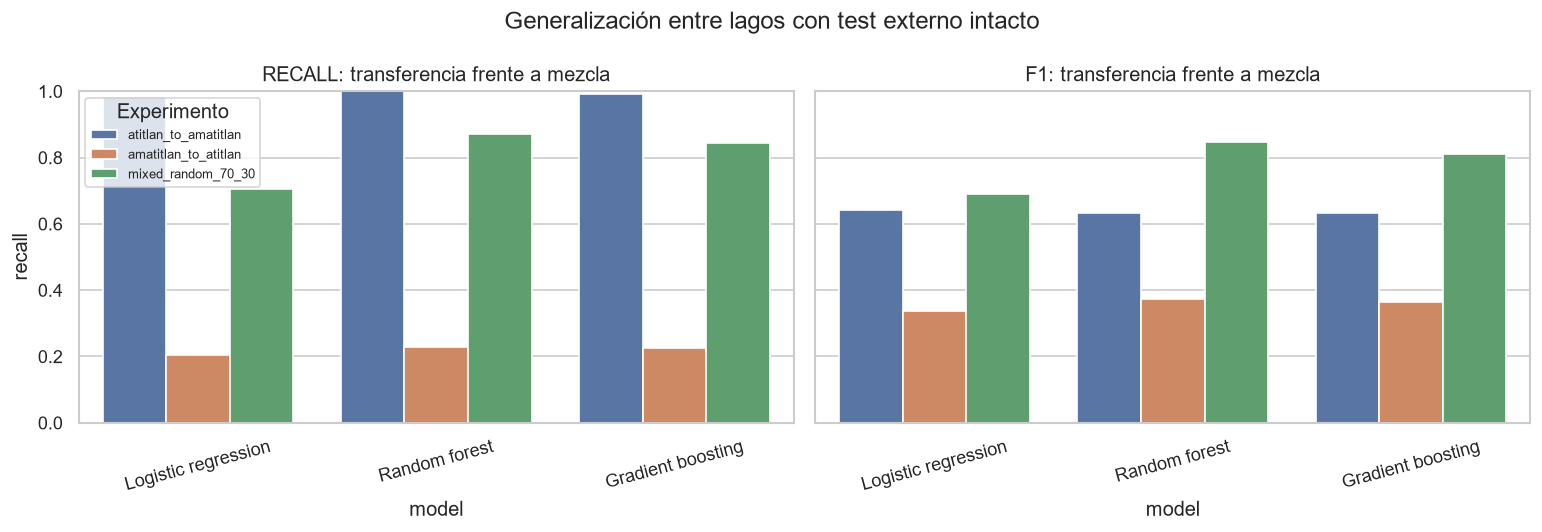

In [16]:
cross_plot = cross_lake_metrics[["experiment", "model", "recall", "f1"]].copy()
mixed_plot = random_metrics[["model", "recall", "f1"]].assign(experiment="mixed_random_70_30")
cross_plot = pd.concat([cross_plot, mixed_plot], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for metric, axis in zip(["recall", "f1"], axes, strict=True):
    sns.barplot(data=cross_plot, x="model", y=metric, hue="experiment", ax=axis)
    axis.set_ylim(0, 1)
    axis.set_title(f"{metric.upper()}: transferencia frente a mezcla")
    axis.tick_params(axis="x", rotation=15)
axes[0].legend(title="Experimento", fontsize=8)
axes[1].get_legend().remove()
plt.suptitle("Generalización entre lagos con test externo intacto")
plt.tight_layout()
display_figure(fig)

### Respuestas 7.4–7.6 e interpretación

La comparación anterior usa como referencia el test aleatorio común con ambos lagos. Esa referencia mezcla espacio, fechas e identidades de lago y, además, tanto ella como los tests externos provienen de la muestra estratificada por lago–fecha–clase. Por ello sus precision, accuracy y matrices son condicionales al diseño de muestreo: no estiman directamente valores predictivos bajo la prevalencia poblacional.

**Respuesta explícita:** los resultados no respaldan una generalización adecuada y equilibrada en ninguno de los dos sentidos. Atitlán→Amatitlán favorece casi indiscriminadamente la clase positiva y Amatitlán→Atitlán conserva precision alta a costa de omitir la mayoría de positivos. Una caída frente a `mixed_random_70_30` indica cambio de dominio: el patrón aprendido en un lago no conserva el mismo desempeño en el otro. Incluso si una métrica aislada mejora, dos lagos y 22 fechas no prueban generalización a otros cuerpos de agua ni a campañas futuras.

Las diferencias observables están en la tabla de contexto: prevalencia poblacional del proxy, intervalos de fechas, cobertura elegible y medias/medianas/dispersión de B02, B03, B08, B11 y B12. Esas diferencias espectrales pueden reflejar combinaciones de material suspendido, color del agua, geometría de adquisición, atmósfera residual o condiciones limnológicas. Diferencias geográficas como morfometría, altitud y presión de cuenca son hipótesis plausibles, pero no están medidas por este dataset y **no se interpretan causalmente**. Para atribución ambiental harían falta muestreos in situ, variables meteorológicas/hidrológicas y validación multisitio representativa.

## Ejercicio 8 — Importancia de variables y SHAP

Se selecciona el modelo con mejor recall promedio (y F1 como desempate) entre las tres estrategias de validación dentro del mismo lago (`random_70_30`, `spatial_groupkfold`, `temporal_future`). La transferencia entre lagos (Ejercicio 7) se deja fuera de este ranking porque responde a una pregunta distinta (cambio de dominio, no desempeño esperado dentro del sistema ya observado).

In [17]:
overall_rank = (
    comparison.groupby("model")[["recall", "f1"]]
    .mean()
    .sort_values(["recall", "f1"], ascending=False)
)
display(overall_rank)

best_model_name = overall_rank.index[0]
best_model = models[best_model_name]
print(f"Modelo seleccionado para interpretabilidad y mapas: {best_model_name}")

,recall,f1
model,,
Random forest,0.8461,0.8190
Gradient boosting,0.8419,0.7832
Logistic regression,0.7243,0.7397


Modelo seleccionado para interpretabilidad y mapas: Random forest


,importance
B08,0.3141
B02,0.2425
B03,0.2127
B11,0.1189
B12,0.1118


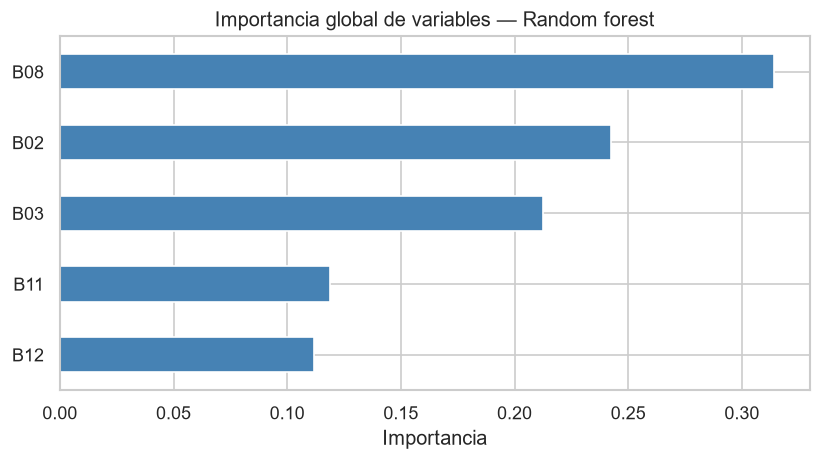

In [18]:
def extract_feature_importance(model, predictors):
    classifier = model.named_steps["classifier"]
    if hasattr(classifier, "feature_importances_"):
        values = classifier.feature_importances_
    elif hasattr(classifier, "coef_"):
        values = np.abs(classifier.coef_[0])
    else:
        raise ValueError("Classifier exposes no importance attribute")
    return pd.Series(values, index=predictors).sort_values(ascending=False)


feature_importance = extract_feature_importance(best_model, PREDICTORS)
feature_importance.to_frame("importance").to_csv(EVIDENCE_DIR / "ml_feature_importance.csv")
display(feature_importance.to_frame("importance"))

fig, ax = plt.subplots(figsize=(7, 4))
feature_importance.sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Importancia")
ax.set_title(f"Importancia global de variables — {best_model_name}")
plt.tight_layout()
display_figure(fig)

ExactExplainer explainer: 301it [00:22,  9.65it/s]                         


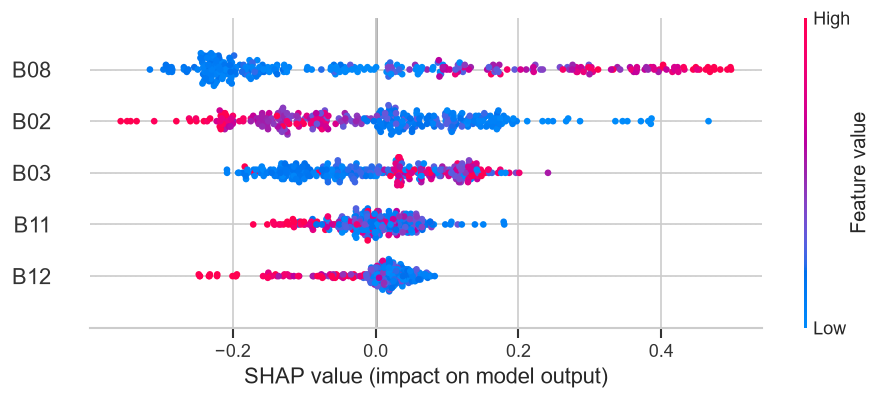

,mean_abs_shap,value_vs_shap_corr
B08,0.2023,0.7390
B02,0.1212,-0.8484
B03,0.0901,0.5153
B11,0.0436,-0.4726
B12,0.0434,-0.8207


In [19]:
import shap

def predict_positive(values):
    frame = pd.DataFrame(values, columns=list(PREDICTORS))
    return best_model.predict_proba(frame)[:, 1]


shap_background = data.iloc[random_train][list(PREDICTORS)].sample(
    min(100, len(random_train)), random_state=RANDOM_STATE
)
shap_sample = data.iloc[random_test][list(PREDICTORS)].sample(
    min(300, len(random_test)), random_state=RANDOM_STATE
)
explainer = shap.Explainer(predict_positive, shap_background)
shap_values = explainer(shap_sample)

shap.summary_plot(shap_values, shap_sample, show=False)
display_figure(plt.gcf())

mean_abs_shap = pd.Series(
    np.abs(shap_values.values).mean(axis=0), index=PREDICTORS
).sort_values(ascending=False)
value_shap_correlation = pd.Series(
    [
        np.corrcoef(shap_sample[predictor], shap_values.values[:, index])[0, 1]
        for index, predictor in enumerate(PREDICTORS)
    ],
    index=PREDICTORS,
)
shap_summary_table = pd.DataFrame(
    {"mean_abs_shap": mean_abs_shap, "value_vs_shap_corr": value_shap_correlation}
).sort_values("mean_abs_shap", ascending=False)
shap_summary_table.to_csv(EVIDENCE_DIR / "ml_shap_summary.csv")
display(shap_summary_table)

**Interpretación 8.3–8.4 (completar con los valores exactos de `shap_summary_table` al ejecutar).** Las bandas con mayor `mean_abs_shap` son las que más mueven la probabilidad estimada de alta cianobacteria; el signo de `value_vs_shap_corr` indica si valores altos de esa banda empujan la predicción hacia 1 (positivo) o hacia 0 (negativo). Por el significado físico de cada banda (véase el catálogo del Ejercicio 3): B02 y B03 responden a dispersión y contraste óptico del agua, B08 a la respuesta de partículas suspendidas en el infrarrojo cercano, y B11/B12 (SWIR) a humedad y contraste agua–tierra. Una contribución fuerte de B11/B12 sugeriría que el modelo distingue aguas más turbias o con mayor carga de sedimentos/material orgánico, coherente con condiciones favorables a floraciones; una contribución fuerte de B02/B03 apuntaría más a color y claridad del agua. Esto es una hipótesis de lectura física y no una prueba causal: los predictores fueron elegidos por no formar el target, pero igual pueden correlacionar con él por vías indirectas (por ejemplo, ambos responden a la misma agua turbia). Cualquier variable con importancia sorprendentemente alta debe revisarse contra el catálogo de fuga del Ejercicio 3 antes de confiar en ella.**Interpretación 8.3–8.4.** La banda más importante es B08 (NIR), con correlación positiva fuerte (0.7390): valores altos empujan la predicción hacia alta cianobacteria, lo cual tiene sentido porque el NIR responde fuerte a partículas y algas en el agua.

La segunda más importante es B02 (azul), con correlación negativa (-0.8484): azul alto empuja hacia baja cianobacteria, azul bajo hacia alta. Esto calza porque el azul se absorbe más en aguas con más materia orgánica.

B03 (verde) tiene importancia media y correlación positiva (0.5153), consistente con más reflejo verde cuando hay más pigmento.

B11 y B12 (SWIR) son las menos importantes (0.0436 y 0.0434) y ambas negativas, aportando poco al modelo.

En resumen: el modelo decide principalmente por el contraste entre B08 alto y B02 bajo, con B03 reforzando esa misma señal. No es prueba de causalidad, solo un patrón espectral consistente con lo esperado físicamente en agua con más partículas o pigmento.

## Ejercicio 9 — Mapas predictivos

In [20]:
from matplotlib.colors import BoundaryNorm, ListedColormap

from lab4_ds.predictive_maps import aggregate_lake_predictions, score_lake_scenes

scored_scenes = score_lake_scenes(best_model)
lake_predictions = {
    lake: aggregate_lake_predictions(scored_scenes, lake) for lake in ("atitlan", "amatitlan")
}

C:\Users\irisa\Documents\Trabajos_UVG\Semestre 8\DataScience\Lab4-ds\src\lab4_ds\predictive_maps.py:61: RuntimeWarning: Mean of empty slice
  mean_probability = np.nanmean(probability_stack, axis=0)
C:\Users\irisa\Documents\Trabajos_UVG\Semestre 8\DataScience\Lab4-ds\src\lab4_ds\predictive_maps.py:62: RuntimeWarning: Mean of empty slice
  mean_target = np.nanmean(target_stack, axis=0)


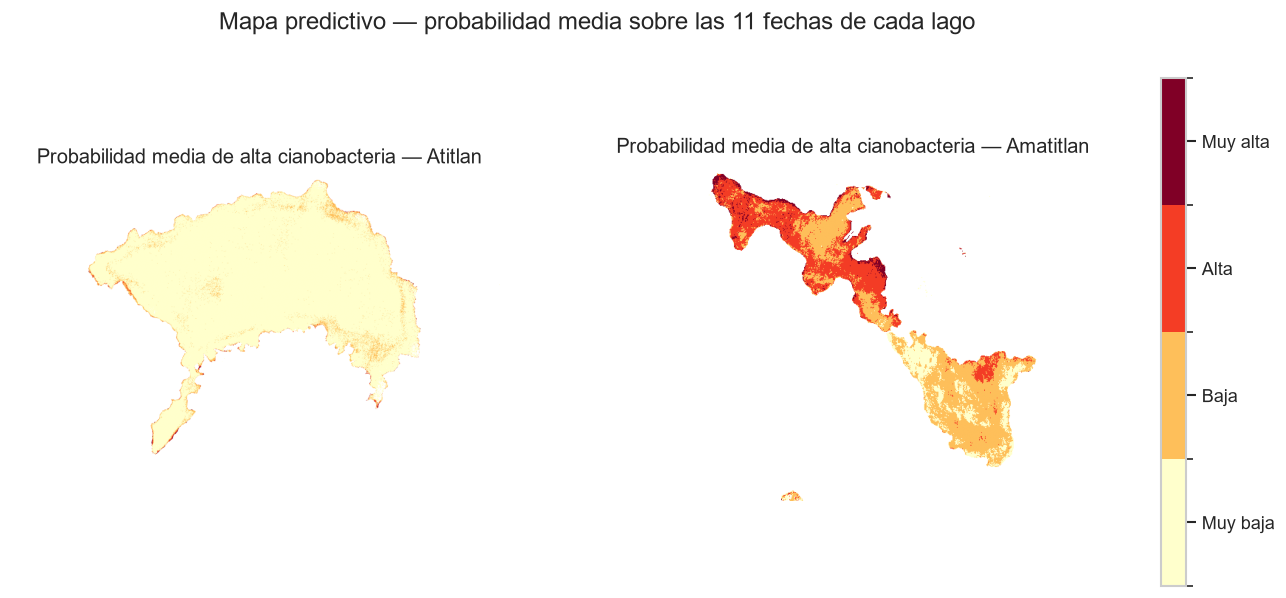

In [21]:
boundaries = [0, 0.25, 0.5, 0.75, 1.0]
probability_labels = ["Muy baja", "Baja", "Alta", "Muy alta"]
probability_cmap = plt.get_cmap("YlOrRd", len(probability_labels))
probability_norm = BoundaryNorm(boundaries, probability_cmap.N)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
image = None
for axis, lake in zip(axes, ("atitlan", "amatitlan"), strict=True):
    probability_map = lake_predictions[lake]["mean_probability"]
    image = axis.imshow(probability_map, cmap=probability_cmap, norm=probability_norm)
    axis.set_title(f"Probabilidad media de alta cianobacteria — {lake.title()}")
    axis.axis("off")
colorbar = fig.colorbar(image, ax=axes, ticks=[0.125, 0.375, 0.625, 0.875], fraction=0.05)
colorbar.ax.set_yticklabels(probability_labels)
plt.suptitle("Mapa predictivo — probabilidad media sobre las 11 fechas de cada lago")
display_figure(fig)

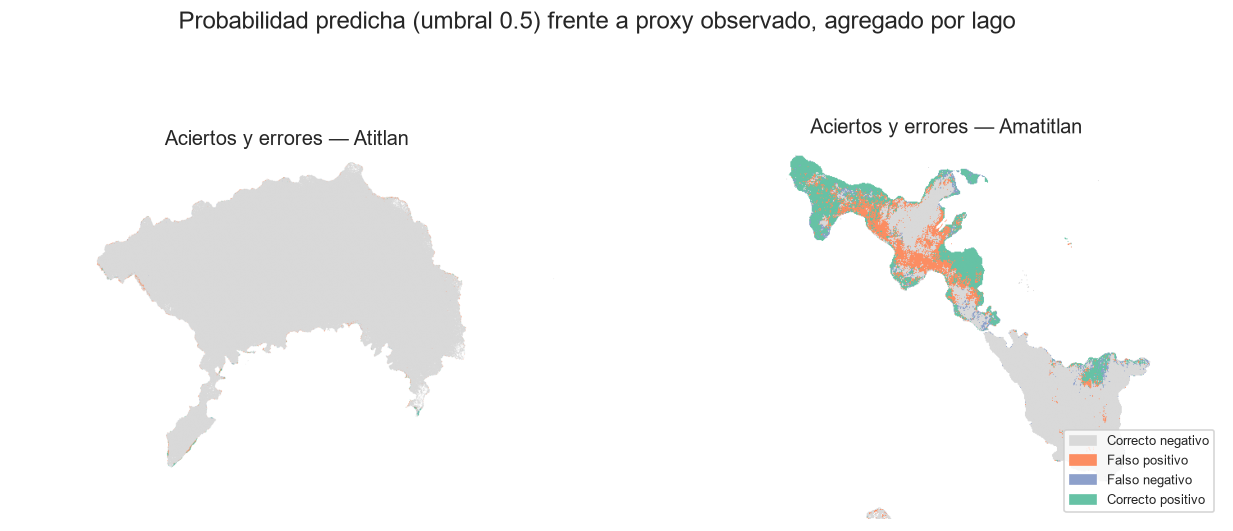

In [22]:
error_labels = ["Correcto negativo", "Falso positivo", "Falso negativo", "Correcto positivo"]
error_colors = ["#d9d9d9", "#fc8d62", "#8da0cb", "#66c2a5"]
error_cmap = ListedColormap(error_colors)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for axis, lake in zip(axes, ("atitlan", "amatitlan"), strict=True):
    prediction = lake_predictions[lake]
    category = np.full(prediction["mean_probability"].shape, np.nan)
    category[prediction["true_negative"]] = 0
    category[prediction["false_positive"]] = 1
    category[prediction["false_negative"]] = 2
    category[prediction["true_positive"]] = 3
    axis.imshow(category, cmap=error_cmap, vmin=0, vmax=3)
    axis.set_title(f"Aciertos y errores — {lake.title()}")
    axis.axis("off")
legend_handles = [plt.Rectangle((0, 0), 1, 1, color=color) for color in error_colors]
axes[1].legend(legend_handles, error_labels, loc="lower right", fontsize=8)
plt.suptitle("Probabilidad predicha (umbral 0.5) frente a proxy observado, agregado por lago")
display_figure(fig)

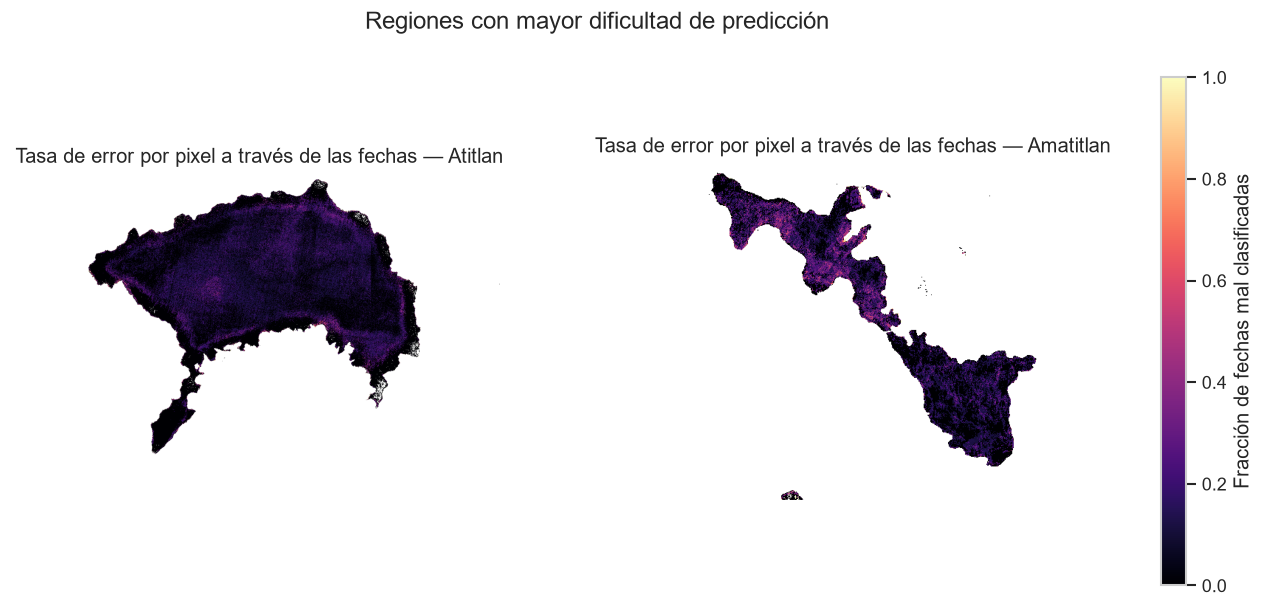

Mapa de hotspots persistentes — Parte I — Atitlan


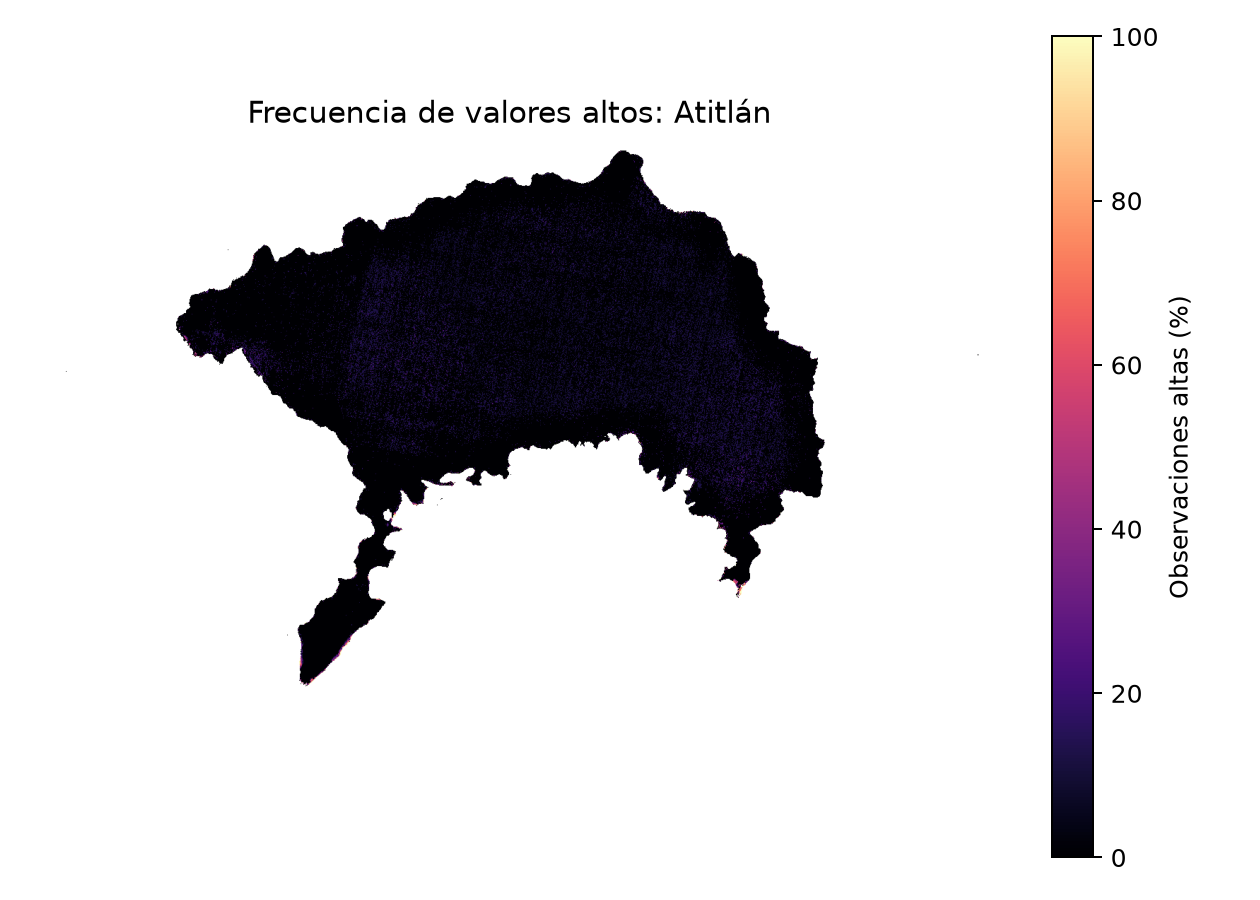

Mapa de hotspots persistentes — Parte I — Amatitlan


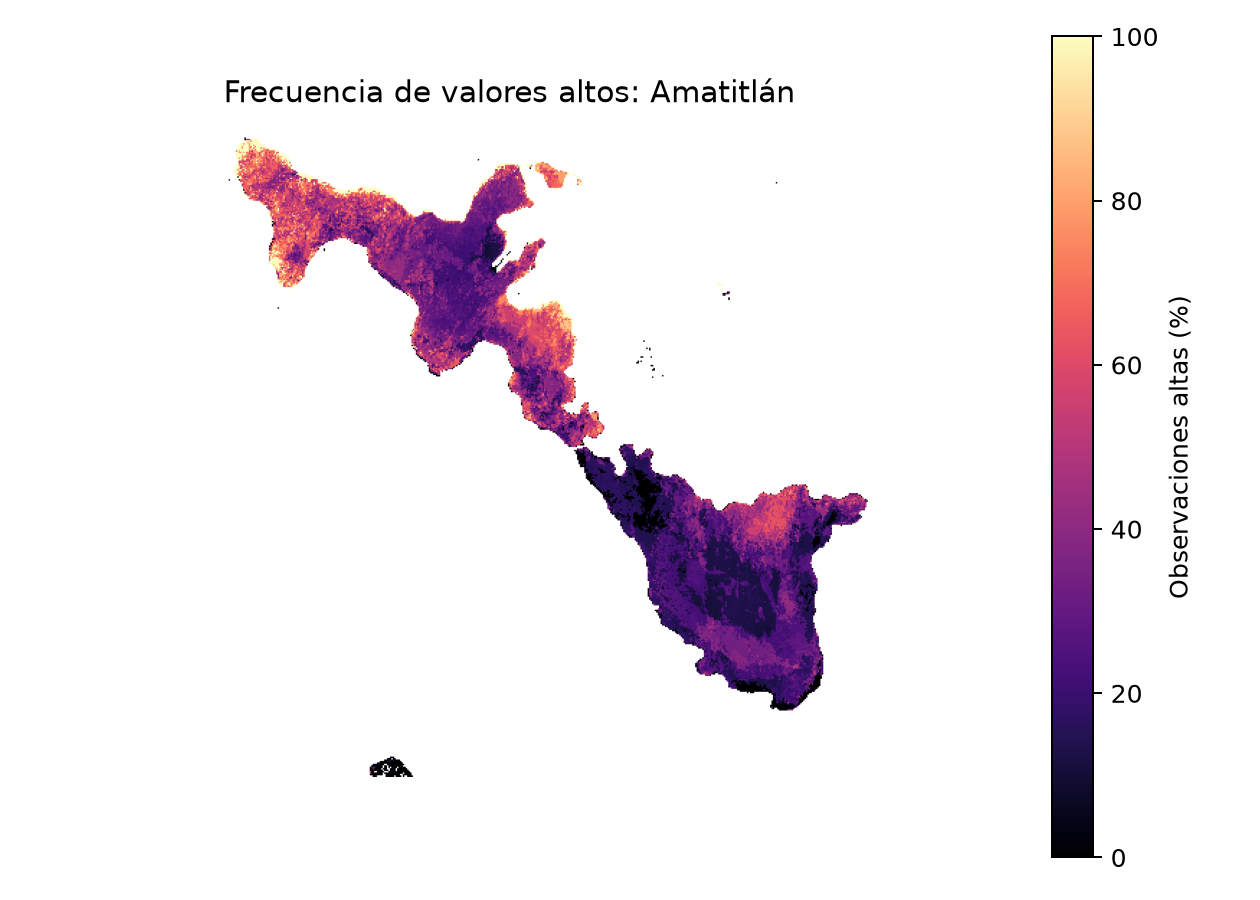

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
image = None
for axis, lake in zip(axes, ("atitlan", "amatitlan"), strict=True):
    image = axis.imshow(lake_predictions[lake]["error_rate"], cmap="magma", vmin=0, vmax=1)
    axis.set_title(f"Tasa de error por pixel a través de las fechas — {lake.title()}")
    axis.axis("off")
fig.colorbar(image, ax=axes, fraction=0.05, label="Fracción de fechas mal clasificadas")
plt.suptitle("Regiones con mayor dificultad de predicción")
display_figure(fig)

for lake in ("atitlan", "amatitlan"):
    hotspot_path = Path(f"outputs/figures/hotspots_{lake}.png")
    if hotspot_path.exists():
        print(f"Mapa de hotspots persistentes — Parte I — {lake.title()}")
        display(Image(filename=str(hotspot_path)))

**Interpretación 9.5–9.7.** El mapa de probabilidad se parece bastante al mapa de hotspots de la Parte I: Amatitlán sale con probabilidad alta en buena parte del lago y Atitlán casi todo en probabilidad muy baja. Eso ya es una señal de que el modelo no está inventando el patrón, está reflejando lo mismo que ya se veía en el proxy original.

En los errores, Atitlán queda casi todo gris (correcto negativo), sin sorpresas. Amatitlán es donde se ve la mayoría de los falsos positivos (naranja), concentrados en la parte norte del lago, que es justo la zona con más probabilidad predicha. O sea el modelo tiende a sobrestimar ahí. Falsos negativos casi no se ven, lo cual es bueno porque significa que casi no se le está escapando una zona que sí tenía cianobacteria alta.

El mapa de tasa de error confirma lo mismo: en Atitlán el error es bajísimo en todo el lago, mientras que en Amatitlán hay más error justo en los bordes de la zona norte, que es donde cambia de alta a baja probabilidad. Tiene sentido que ahí sea donde más se equivoca, porque es la zona de transición donde el patrón espectral es menos estable entre fechas.

## Ejercicio 10 — Análisis y conclusiones

**10.1 — ¿El modelo tiene capacidad suficiente como herramienta de apoyo?** El modelo elegido fue random forest, con recall de 0.87 en la validación aleatoria, 0.87 en la espacial y 0.80 en la temporal. Con esos números sí sirve como apoyo para priorizar dónde monitorear, porque detecta la mayoría de las zonas con cianobacteria alta, aunque a veces marque de más (mejor eso que dejar pasar una zona real).

El problema es cuando se prueba entre lagos (Ejercicio 7). Entrenado en Atitlán y probado en Amatitlán, el modelo predice casi todo como positivo: recall de 1.00 pero precision de solo 0.46 y especificidad de 0.03, básicamente dice "sí" casi siempre. Al revés, entrenado en Amatitlán y probado en Atitlán, se vuelve muy conservador: recall de apenas 0.23, se le escapan 2265 positivos reales. Esto confirma que el modelo no aprendió una firma universal de cianobacteria, aprendió el contexto espectral específico de cada lago. Entonces sirve como apoyo, pero solo dentro de los lagos y el periodo con el que se entrenó, no en un lago nuevo sin reentrenar.

**10.2 — Limitaciones principales.**
- La clase positiva es solo 5.04% del total (18.85 negativos por cada positivo), un desbalance fuerte incluso usando pesos balanceados.
- Solo 22 escenas (11 fechas por lago) y resolución de 20 m/pixel en vez de 10 m, porque el límite de la API era 2500 píxeles por lado para Atitlán. Menos detalle y menos fechas significa más incertidumbre en todas las validaciones.
- La nubosidad en algunas fechas de Amatitlán reduce el área útil disponible en esas escenas.
- No hay ninguna variable ambiental (temperatura, profundidad, nutrientes) que explique por qué los dos lagos son tan distintos espectralmente; el modelo solo ve correlación espectral, no la causa real.
- El entrenamiento usa una muestra estratificada (hasta 500 por clase por escena), no una muestra representativa de campo, así que precision y accuracy describen ese diseño de muestreo, no necesariamente lo que pasaría con datos de campo reales.
- El target es un proxy (NDCI transformado a clorofila-a más FAI), no una medición de laboratorio ni una confirmación de cianobacteria tóxica real.

**10.3 — Qué datos adicionales ayudarían.** Datos de temperatura y precipitación por lago (como las fuentes de Weatherspark que ya venían en las instrucciones) para relacionar los picos con clima y no solo con la fecha. Datos hidrológicos como profundidad y entrada de nutrientes, que podrían explicar por qué el modelo no transfiere entre lagos. Muestreos físicos de clorofila-a y toxinas para confirmar si el proxy satelital corresponde a floraciones reales. Y más fechas por lago para que las validaciones espacial y temporal tengan menos incertidumbre.